# Deep Learning - Clasificación

## Definición del problema

En este notebook vamos a desarrollar modelos de redes neuronales multicapa densas para resolver un problema de clasificación. El objetivo consiste en clasificar a los sujetos como sanos o enfermos (cáncer de hígado) a partir de los niveles de expresión génica de 22278 genes. Los datos están disponibles gratuitamente en el sitio web oficial de CuMiDa con el id 14520_U133A: https://sbcb.inf.ufrgs.br/cumida

In [ ]:
# @title Cargar paquetes y módulos necesarios
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt # importamos matplotlib como plt
import seaborn as sns # importamos seaborn como sns
sns.set_style("ticks")
%config InlineBackend.figure_format = 'retina'

import plotly.express as px

# Descompresión de los ficheros en nuestra carpeta de contenido
import os
import zipfile

# paquete para la conexión y descarga de ficheros alojados en google drive
!pip install gdown
import gdown

from google.colab import drive

# Módulos para redes neuronales
import tensorflow as tf
from tensorflow import keras
import keras

from datetime import datetime

In [ ]:
#@title Carga de clases de Scikit-learn y Keras
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA

# Keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
from keras.layers import Dropout
from keras.optimizers import SGD, Adam
from keras import regularizers
from keras.layers import BatchNormalization

En primer lugar vamos a montar Google Drive para guardar los conjuntos de datos, modelos, etc. que se generen y no perderlos. De esta manera podemos recuperarlos más tarde para seguir con el estudio.

In [ ]:
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [ ]:
path = '/content/drive/MyDrive/DL'

Vamos a crear primero una función para ver las gráficas de las función de *loss* y la métrica de evaluación elegida.

In [ ]:
def plot_train_history(history, metric, label_metric):
  plt.plot(history.history['loss'], label='Valor de pérdida')
  plt.plot(history.history[metric], label=label_metric)
  plt.title('Entrenamiento')
  plt.xlabel('Épocas')
  plt.legend(loc="upper left")
  plt.show()

## Pasos a realizar para la consecución de la tarea

*   Carga del banco de datos
*   Análisis exploratorio de los datos y preprocesado
*   Desarrollo de un modelo basal de red neuronal
*   Alternativas para mejorar el modelo basal

In [ ]:
# @title Carga del banco de datos

# Descarganos fichero comprimido
id = "1hQce6XfoPLDS61fNx4nkWAASIb5tvArM"
gdown.download(id=id, output="liver.zip")

# Descomprimimos
local_zip = '/content/liver.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content')
zip_ref.close()

# Cargamos
liver = pd.read_csv('/content/Liver.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1hQce6XfoPLDS61fNx4nkWAASIb5tvArM
From (redirected): https://drive.google.com/uc?id=1hQce6XfoPLDS61fNx4nkWAASIb5tvArM&confirm=t&uuid=5fcaf465-4ef3-4b5d-96cd-1798241bbeef
To: /content/liver.zip
100%|██████████| 62.1M/62.1M [00:01<00:00, 55.2MB/s]


In [ ]:
# Eliminamos la variable que identifica la muestra
liver = liver.drop(columns=['samples'])

In [ ]:
# Vemos las primeras cinco muestras
liver.head(5)

,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,HCC,6.801198,4.553189,6.787790,5.430893,3.250222,6.272688,3.413405,3.374910,3.654116,...,10.735084,10.398843,12.298551,12.270505,3.855588,3.148321,3.366087,3.199008,3.160388,3.366417
1,HCC,7.585956,4.193540,3.763183,6.003593,3.309387,6.291927,3.754777,3.587603,5.137159,...,11.528447,11.369919,12.867048,12.560433,4.016561,3.282867,3.541994,3.548680,3.460083,3.423348
2,HCC,7.803370,4.134075,3.433113,5.395057,3.476944,5.825713,3.505036,3.687333,4.515175,...,10.892460,10.416151,12.356337,11.888482,3.839367,3.598851,3.516791,3.484089,3.282626,3.512024
3,HCC,6.920840,4.000651,3.754500,5.645297,3.387530,6.470458,3.629249,3.577534,5.192624,...,10.686871,10.524836,12.006596,11.846195,3.867602,3.180472,3.309547,3.425501,3.166613,3.377499
4,HCC,6.556480,4.599010,4.066155,6.344537,3.372081,5.439280,3.762213,3.440714,4.961625,...,11.014454,10.775566,12.657182,12.573076,4.091440,3.306729,3.493704,3.205771,3.378567,3.392938


In [ ]:
#@title Número de muestras y numero de variables
print(f'El banco de datos tiene {liver.shape[0]} muestras y {liver.shape[1]} variables.')

El banco de datos tiene 357 muestras y 22278 variables.


## Preprocesado de los datos y EDA

In [ ]:
print(liver.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Columns: 22278 entries, type to AFFX-TrpnX-M_at
dtypes: float64(22277), object(1)
memory usage: 60.7+ MB
None


In [ ]:
# Tipo de las columnas
liver.dtypes

,0
type,object
1007_s_at,float64
1053_at,float64
117_at,float64
121_at,float64
...,...
AFFX-ThrX-5_at,float64
AFFX-ThrX-M_at,float64
AFFX-TrpnX-3_at,float64
AFFX-TrpnX-5_at,float64


Como vemos, todas las columnas son de tipo numérico excepto la columna *type* que será nuestra variable objetuvo o Target.

In [ ]:
# Comprobación de missing values
missing = liver.isnull().sum()
print(missing)
# Suma de los valores perdidos por columna para comprobar si hay alguno (hay demasiadas columnas y no vemos el resultado de todas)
missing.sum()

type               0
1007_s_at          0
1053_at            0
117_at             0
121_at             0
                  ..
AFFX-ThrX-5_at     0
AFFX-ThrX-M_at     0
AFFX-TrpnX-3_at    0
AFFX-TrpnX-5_at    0
AFFX-TrpnX-M_at    0
Length: 22278, dtype: int64


0

No tenemos valores perdidos en ninguna de las columnas. Vamos ahora a codificar la variable objetivo *type* y estandarizar las variables numéricas.

In [ ]:
# Nombres de variables numéricas
str_num_var = liver.select_dtypes(include=['float64']).columns.values
# Nombres de variables categóricas
str_cat_var = liver.select_dtypes(include=['object']).columns.values
# Escalamos y codificamos
transformer = make_column_transformer(
    (StandardScaler(), str_num_var),
    (OneHotEncoder(), str_cat_var),
    verbose_feature_names_out=False)

# Matriz de datos con variables preprocesadas
transformed = transformer.fit_transform(liver)
liver_df = pd.DataFrame(transformed, columns=transformer.get_feature_names_out())

Vemos las primeras muestras del dataframe.

In [ ]:
liver_df.head()

,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at,type_HCC,type_normal
0,-0.149175,0.365217,6.099383,-0.757729,0.456567,0.713222,-1.663846,-1.099900,-1.386418,-2.652276,...,-2.053513,-1.527354,-0.929856,-0.772452,-0.743016,-0.189244,-0.367012,0.555976,1.0,0.0
1,0.838733,-0.331300,-0.512948,1.011581,0.960557,0.755060,-0.133063,0.355164,0.019279,-0.870413,...,-0.600777,-0.893883,-0.809623,-0.554660,-0.545344,1.912950,2.246443,0.926435,1.0,0.0
2,1.112429,-0.446464,-1.234539,-0.868440,2.387877,-0.258837,-1.252954,1.037434,-0.570266,0.630890,...,-1.905848,-2.362047,-0.941971,-0.043169,-0.573665,1.524638,0.698948,1.503457,1.0,0.0
3,0.001439,-0.704860,-0.531929,-0.095346,1.626216,1.143321,-0.695955,0.286283,0.071851,0.289857,...,-2.799575,-2.454442,-0.920882,-0.720408,-0.806552,1.172408,-0.312727,0.628088,1.0,0.0
4,-0.457242,0.453957,0.149404,2.064896,1.494614,-1.099229,-0.099717,-0.649723,-0.147101,-0.243079,...,-1.137067,-0.866259,-0.753696,-0.516033,-0.599609,-0.148584,1.535590,0.728551,1.0,0.0


Vemos ahora las columnas:

In [ ]:
liver_df.columns

Index(['1007_s_at', '1053_at', '117_at', '121_at', '1255_g_at', '1294_at',
       '1316_at', '1320_at', '1405_i_at', '1431_at',
       ...
       'AFFX-r2-P1-cre-3_at', 'AFFX-r2-P1-cre-5_at', 'AFFX-ThrX-3_at',
       'AFFX-ThrX-5_at', 'AFFX-ThrX-M_at', 'AFFX-TrpnX-3_at',
       'AFFX-TrpnX-5_at', 'AFFX-TrpnX-M_at', 'type_HCC', 'type_normal'],
      dtype='object', length=22279)

Vamos ahora a eliminar la columna type_normal, ya que es redundante al tener type_HCC como respuesta.

In [ ]:
liver_df.drop(columns='type_normal', inplace=True)

In [ ]:
liver_df.columns

Index(['1007_s_at', '1053_at', '117_at', '121_at', '1255_g_at', '1294_at',
       '1316_at', '1320_at', '1405_i_at', '1431_at',
       ...
       'AFFX-r2-Ec-bioD-5_at', 'AFFX-r2-P1-cre-3_at', 'AFFX-r2-P1-cre-5_at',
       'AFFX-ThrX-3_at', 'AFFX-ThrX-5_at', 'AFFX-ThrX-M_at', 'AFFX-TrpnX-3_at',
       'AFFX-TrpnX-5_at', 'AFFX-TrpnX-M_at', 'type_HCC'],
      dtype='object', length=22278)

Separamos ahora el dataframe en X (matriz de características o variables predictoras) e y (respuesta).

In [ ]:
X = liver_df.drop(columns=['type_HCC'])
y = liver_df['type_HCC']

Dividimos los datos en entrenamiento (80%) y test (20%), estratificando de forma adecuada.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

Guardamos ahora los conjuntos generados para poder recuperarlos en sesiones posteriores.

In [ ]:
X_train.to_pickle(f'{path}/liver_X_train.pkl')
X_test.to_pickle(f'{path}/liver_X_test.pkl')
y_train.to_pickle(f'{path}/liver_y_train.pkl')
y_test.to_pickle(f'{path}/liver_y_test.pkl')

Como hemos visto antes, tenemos únicamente 357 muestras y 22278 variables, es decir, que tenemos una dimensionalidad muy alta. Por ello, vamos a aplicar PCA para obtener nuevas variables predictoras o características con las que trabajar.

## PCA

En primer lugar hay que determinar el número óptimo de componentes y para ello se utiliza el porcentaje de varianza explicada. En concreto vamos a estudiar la evolución de la varianza explicada acumulada en función del número de componentes hasta que alcancemos un valor que considerado adecuado.

In [ ]:
# Modelo
pca = PCA().fit(X)

exp_var_cumul = np.cumsum(pca.explained_variance_ratio_)

fig = px.area(
    x=range(1, exp_var_cumul.shape[0] + 1),
    y=exp_var_cumul,
    labels={"x": "Numero de componentes", "y": "Varianza explicada"}
)

fig.update_layout(
    title="Varianza explicada acumulada",
    xaxis_title="Numero de componentes",
    yaxis_title="Varianza explicada"
)

fig.update_xaxes(
    tickmode='array',
    tickvals=np.arange(0, exp_var_cumul.shape[0] + 1, 10)
)

fig.update_yaxes(
    tickmode='array',
    tickvals=np.arange(0, 1.1, 0.1)
)

fig.show()

Podemos ver en el gráfico que con 200 componentes conseguimos describir el 90% de la varianza y 356 componentes el 100%. Vamos a quedarnos con esas 200 componentes que nos ayudan a explicar el 90% de la variabilidad contenida en los datos originales.


Vamos a pasar los valores del gráfico a una tabla para verlos mejor ya que no podemos representarlos gráficamente por el alto número de variables.

In [ ]:
# Varianza explicada y acumulada
componentes = np.arange(pca.n_components_) + 1
cumVar = pd.DataFrame(np.cumsum(pca.explained_variance_ratio_)*100, columns=["Varianza acumulada"])
expVar = pd.DataFrame(pca.explained_variance_ratio_*100, columns=["Varianza explicada"])
pd.options.display.float_format = '{:.4f}'.format
pd.concat([expVar, cumVar], axis=1).set_index(componentes)

,Varianza explicada,Varianza acumulada
1,15.8775,15.8775
2,7.2713,23.1488
3,4.5734,27.7222
4,4.0467,31.7689
5,3.6073,35.3762
...,...,...
353,0.0337,99.9041
354,0.0333,99.9374
355,0.0332,99.9706
356,0.0294,100.0000


In [ ]:
# Volvemos a cargar los datos guardados con pickle
X_train = pd.read_pickle(f'{path}/liver_X_train.pkl')
X_test = pd.read_pickle(f'{path}/liver_X_test.pkl')
y_train = pd.read_pickle(f'{path}/liver_y_train.pkl')
y_test = pd.read_pickle(f'{path}/liver_y_test.pkl')

Aplicamos ahora la reducción de la dimensionalidad con 200 componentes a los datos.

In [ ]:
pca = PCA(n_components=200)
X_train_pca = pd.DataFrame(pca.fit_transform(X_train))
X_test_pca = pd.DataFrame(pca.transform(X_test))

In [ ]:
# Guardamos los datos tras haber reducido su dimensionalidad
X_train_pca.to_pickle(f'{path}/liver_X_train_pca.pkl')
X_test_pca.to_pickle(f'{path}/liver_X_test_pca.pkl')

## Carga de los conjuntos de entrenamiento y test

In [ ]:
# Leemos los conjuntos de entrenamiento y test con pca ya aplicado
X_train = pd.read_pickle(f'{path}/liver_X_train_pca.pkl')
X_test = pd.read_pickle(f'{path}/liver_X_test_pca.pkl')
y_train = pd.read_pickle(f'{path}/liver_y_train.pkl')
y_test = pd.read_pickle(f'{path}/liver_y_test.pkl')

## Modelo basal

A continuación se propone un modelo de red neuronal básico, que servirá como punto de partida para comparar los cambios de hiperparámetros.

El modelo de partida estará compuesto por:

* Una capa oculta de entrada con 8 neuronas y función de activación relu
* Una capa de salida con 1 neurona (ya que es un problema de clasificación binaria) y función de activación sigmoid.
* Función de pérdida binary_crossentropy con optimizador sgd
* Métrica de evaluación del porcentaje de clasificación correcta (accuracy).
* En el periodo de entrenamiento consideramos un bacth size igual a 5 (ya que tenemos pocas muestras) y 5 epochs (para estimar los tiempos que nos llevará de entrenamiento).

En el caso de que no hubiesemos aplicado PCA, tendríamos que aumentar el número de neuronas en las capas ocultas para poder capturar toda la información de las variables. No obstante, al quedarnos únicamente con 200 características, podemos emplear redes más sencillas.

In [ ]:
initializer = tf.keras.initializers.GlorotNormal(123)

# Arquitectura de red
modelo_liver_00 = keras.Sequential([
    Input(shape=(X_train.shape[1],)),  # Forma de entrada
    Dense(8, activation='relu', kernel_initializer=initializer),
    Dense(1, activation='sigmoid')
])

# Resumen del modelo
print("Resumen del modelo")
print("======================")
modelo_liver_00.summary()

# Proceso de aprendizaje
modelo_liver_00.compile(loss = 'binary_crossentropy', optimizer = 'SGD', metrics = ['accuracy'])

# Entrenamiento de la red
print("\n Entrenamiento de la red")
print("=============================")
history_liver_00 = modelo_liver_00.fit(X_train, y_train, batch_size = 5, epochs = 5, verbose = True)

# Evaluación del modelo
print("\n Evaluación de la red")
print("=========================")
test_loss_liver_00, test_acc_liver_00 = modelo_liver_00.evaluate(X_test, y_test)

Resumen del modelo
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 8)                 1608      
                                                                 
 dense_5 (Dense)             (None, 1)                 9         
                                                                 
Total params: 1617 (6.32 KB)
Trainable params: 1617 (6.32 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

 Entrenamiento de la red
Epoch 1/5
57/57 [==============================] - 2s 4ms/step - loss: 0.8175 - accuracy: 0.9088
Epoch 2/5
57/57 [==============================] - 0s 4ms/step - loss: 0.0901 - accuracy: 0.9825
Epoch 3/5
57/57 [==============================] - 0s 4ms/step - loss: 0.0116 - accuracy: 0.9930
Epoch 4/5
57/57 [==============================] - 0s 4ms/step - loss: 0.0084 - ac

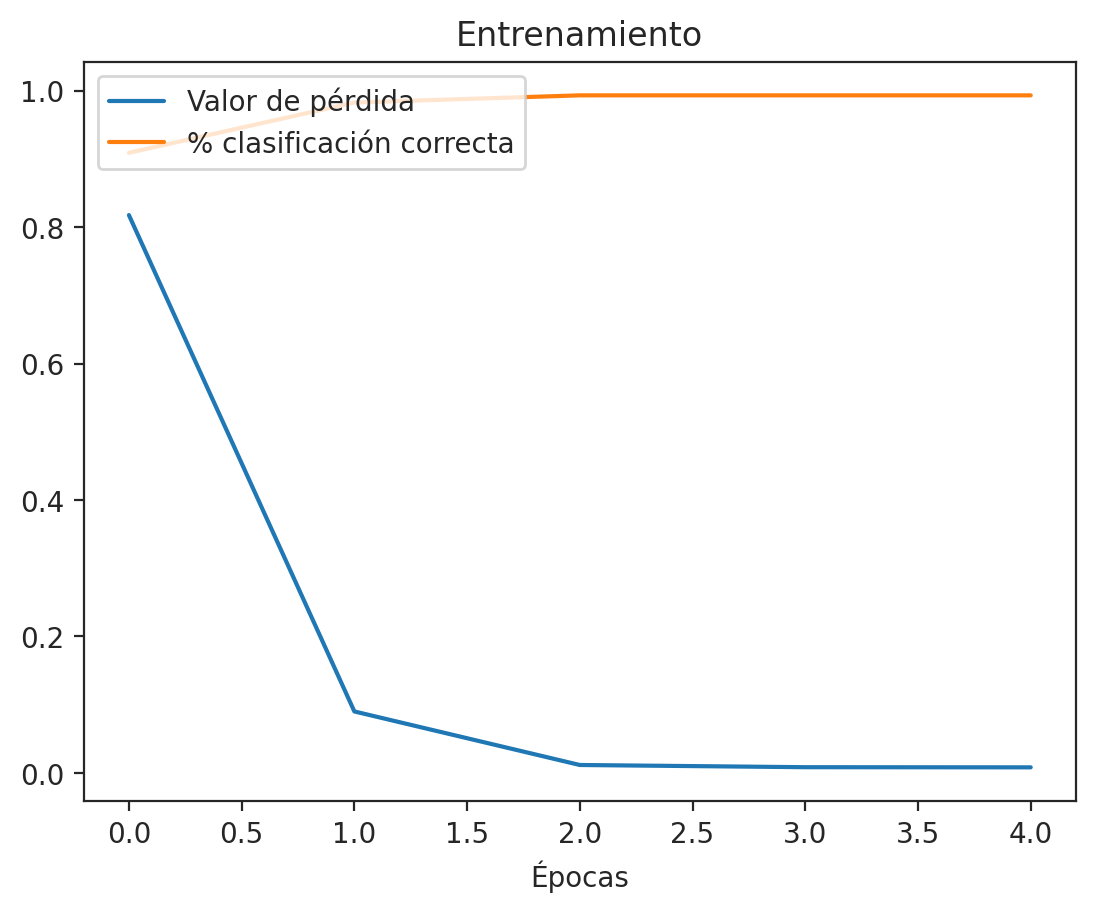

In [ ]:
# Vamos a ver la gráfica resultante
plot_train_history(history_liver_00, 'accuracy', '% clasificación correcta')

El resultado de la red indica que existe sobreajuste (*overfitting*), ya que el porcentaje de clasificación correcta (*accuracy*) es del 99% en el conjunto de entrenamiento, mientras que es del 93% en el conjunto de prueba (test). Además, el valor de *loss* en el conjunto de prueba (0.7570) es significativamente más elevado en comparación con el valor de *loss* en el conjunto de entrenamiento, lo que evidencia la existencia de *overfitting*. Guardamos ahora el modelo de red neuronal entrenado.

In [ ]:
# Guardamos el modelo
modelo_liver_00.save(f'{path}/model_liver_v01.keras')

## Mejora del modelo basal

Dado que en el modelo basal existe overfitting, vamos a intentar mejorar esa situación aplicando técnicas de regularización. En concreto vamos a aplicar:
* Dropout
* Batch normalization
* Penalización de norma L2 (elegimos L2 y no L1, porque es la elegida para el sobreajuste general y aplica una regulación más suave que la L1).

### Regularizacion L2

In [ ]:
# Regularizacion L2
initializer = tf.keras.initializers.GlorotNormal(123)

# Arquitectura de red
modelo_liver_regL2 = keras.Sequential([
    Input(shape=(X_train.shape[1],)),  # Forma de entrada
    Dense(8, activation='relu', kernel_initializer=initializer, kernel_regularizer=regularizers.l2(0.001)),
    Dense(1, activation='sigmoid', kernel_regularizer=regularizers.l2(0.001))
])

# Resumen del modelo
print("Resumen del modelo")
print("======================")
modelo_liver_regL2.summary()

# Proceso de aprendizaje
modelo_liver_regL2.compile(loss = 'binary_crossentropy', optimizer = 'SGD', metrics = ['accuracy'])

# Entrenamiento de la red
print("\n Entrenamiento de la red")
print("=============================")
history_liver_regL2 = modelo_liver_regL2.fit(X_train, y_train, batch_size = 5, epochs = 5, verbose = True)

# Evaluación del modelo
print("\n Evaluación de la red")
print("=========================")
test_loss_liver_regL2, test_acc_liver_regL2 = modelo_liver_regL2.evaluate(X_test, y_test)

Resumen del modelo
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 8)                 1608      
                                                                 
 dense_7 (Dense)             (None, 1)                 9         
                                                                 
Total params: 1617 (6.32 KB)
Trainable params: 1617 (6.32 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

 Entrenamiento de la red
Epoch 1/5
57/57 [==============================] - 1s 2ms/step - loss: 0.7545 - accuracy: 0.9053
Epoch 2/5
57/57 [==============================] - 0s 2ms/step - loss: 0.1811 - accuracy: 0.9579
Epoch 3/5
57/57 [==============================] - 0s 3ms/step - loss: 0.0675 - accuracy: 0.9825
Epoch 4/5
57/57 [==============================] - 0s 3ms/step - loss: 0.0451 - ac

#### Gráfica resultante del entrenamiento

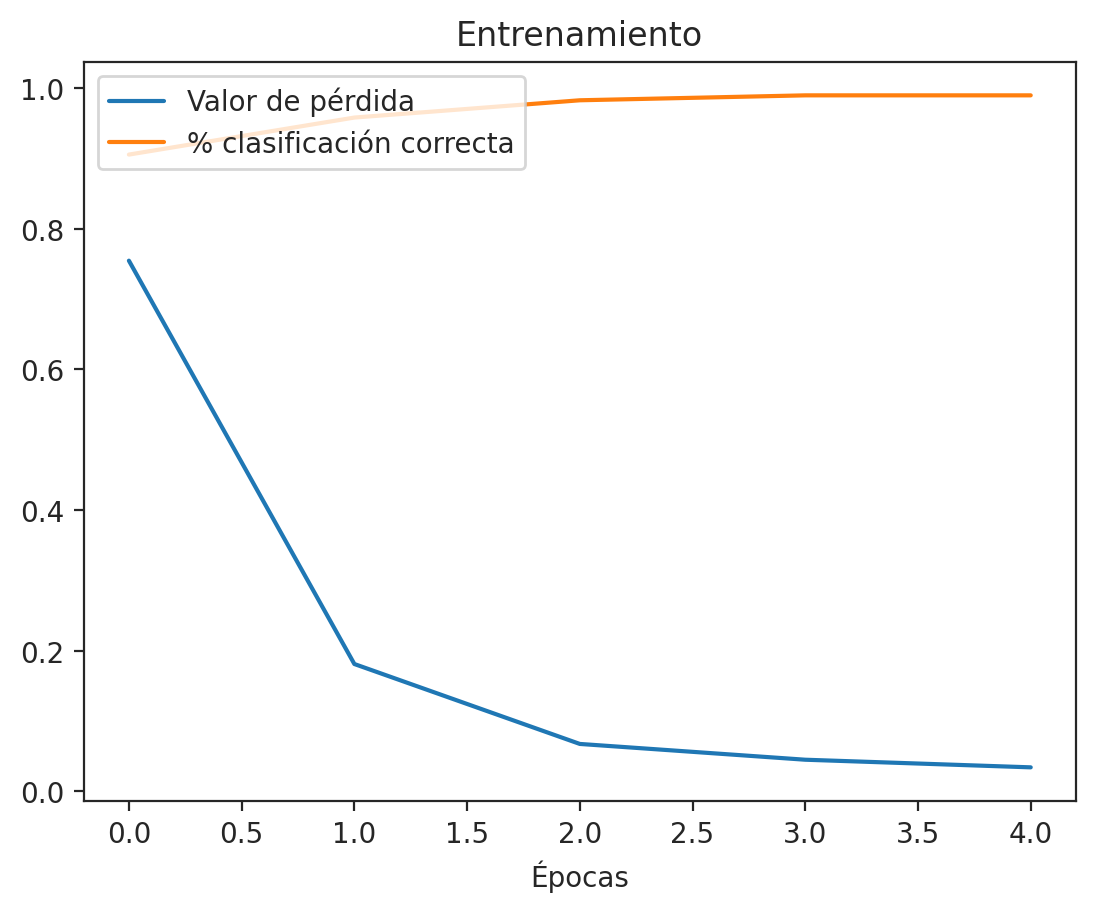

In [ ]:
# Pintamos ahorala gráfica
plot_train_history(history_liver_regL2, 'accuracy', '% clasificación correcta')

### Dropout

In [ ]:
# Dropout
initializer = tf.keras.initializers.GlorotNormal(123)

# Arquitectura de red
modelo_liver_dropout = keras.Sequential([
    Input(shape=(X_train.shape[1],)),  # Forma de entrada
    Dense(8, activation='relu', kernel_initializer=initializer),
    Dropout(0.5),  # Apaga el 50% de las neuronas en esta capa durante el entrenamiento
    Dense(1, activation='sigmoid')
])

# Resumen del modelo
print("Resumen del modelo")
print("======================")
modelo_liver_dropout.summary()

# Proceso de aprendizaje
modelo_liver_dropout.compile(loss = 'binary_crossentropy', optimizer = 'SGD', metrics = ['accuracy'])

# Entrenamiento de la red
print("\n Entrenamiento de la red")
print("=============================")
history_liver_dropout = modelo_liver_dropout.fit(X_train, y_train, batch_size = 5, epochs = 5, verbose = True)

# Evaluación del modelo
print("\n Evaluación de la red")
print("=========================")
test_loss_liver_dropout, test_acc_liver_dropout = modelo_liver_dropout.evaluate(X_test, y_test)

Resumen del modelo
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 8)                 1608      
                                                                 
 dropout (Dropout)           (None, 8)                 0         
                                                                 
 dense_9 (Dense)             (None, 1)                 9         
                                                                 
Total params: 1617 (6.32 KB)
Trainable params: 1617 (6.32 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

 Entrenamiento de la red
Epoch 1/5
57/57 [==============================] - 3s 5ms/step - loss: 2.2686 - accuracy: 0.7684
Epoch 2/5
57/57 [==============================] - 0s 5ms/step - loss: 0.5344 - accuracy: 0.8912
Epoch 3/5
57/57 [==============================

#### Gráfica resultante del entrenamiento

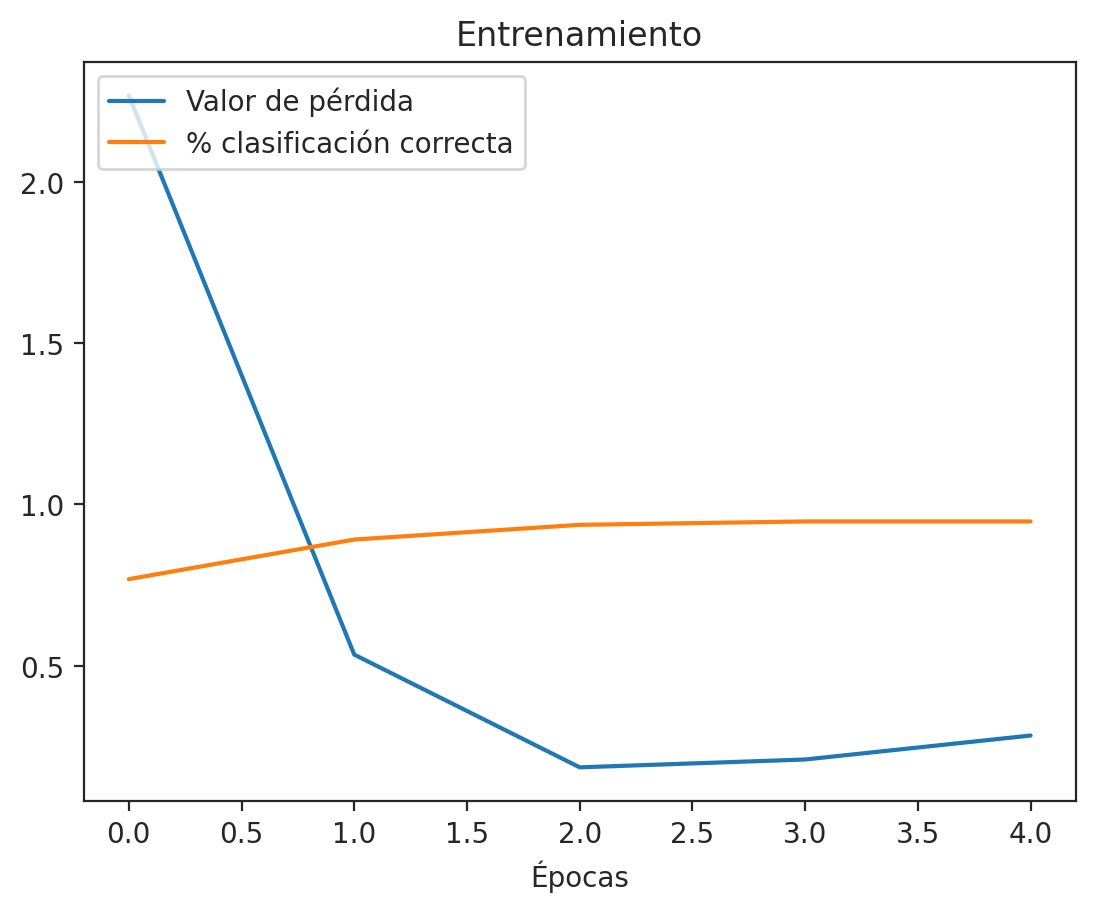

In [ ]:
plot_train_history(history_liver_dropout, 'accuracy', '% clasificación correcta')

### Batch normalization

In [ ]:
# Dropout
initializer = tf.keras.initializers.GlorotNormal(123)

# Arquitectura de red
modelo_liver_bNorm = keras.Sequential([
    Input(shape=(X_train.shape[1],)),  # Forma de entrada
    Dense(8, activation='relu', kernel_initializer=initializer),
    BatchNormalization(),  # Normaliza la salida de la capa anterior
    Dense(1, activation='sigmoid')
])

# Resumen del modelo
print("Resumen del modelo")
print("======================")
modelo_liver_bNorm.summary()

# Proceso de aprendizaje
modelo_liver_bNorm.compile(loss = 'binary_crossentropy', optimizer = 'SGD', metrics = ['accuracy'])

# Entrenamiento de la red
print("\n Entrenamiento de la red")
print("=============================")
history_liver_bNorm = modelo_liver_bNorm.fit(X_train, y_train, batch_size = 5, epochs = 5, verbose = True)

# Evaluación del modelo
print("\n Evaluación de la red")
print("=========================")
test_loss_liver_bNorm, test_acc_liver_bNorm = modelo_liver_bNorm.evaluate(X_test, y_test)

Resumen del modelo
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_10 (Dense)            (None, 8)                 1608      
                                                                 
 batch_normalization (Batch  (None, 8)                 32        
 Normalization)                                                  
                                                                 
 dense_11 (Dense)            (None, 1)                 9         
                                                                 
Total params: 1649 (6.44 KB)
Trainable params: 1633 (6.38 KB)
Non-trainable params: 16 (64.00 Byte)
_________________________________________________________________

 Entrenamiento de la red
Epoch 1/5
57/57 [==============================] - 2s 5ms/step - loss: 0.4755 - accuracy: 0.7930
Epoch 2/5
57/57 [==============================] - 0s 5ms/step - loss: 0.283

#### Gráfica resultante del entrenamiento

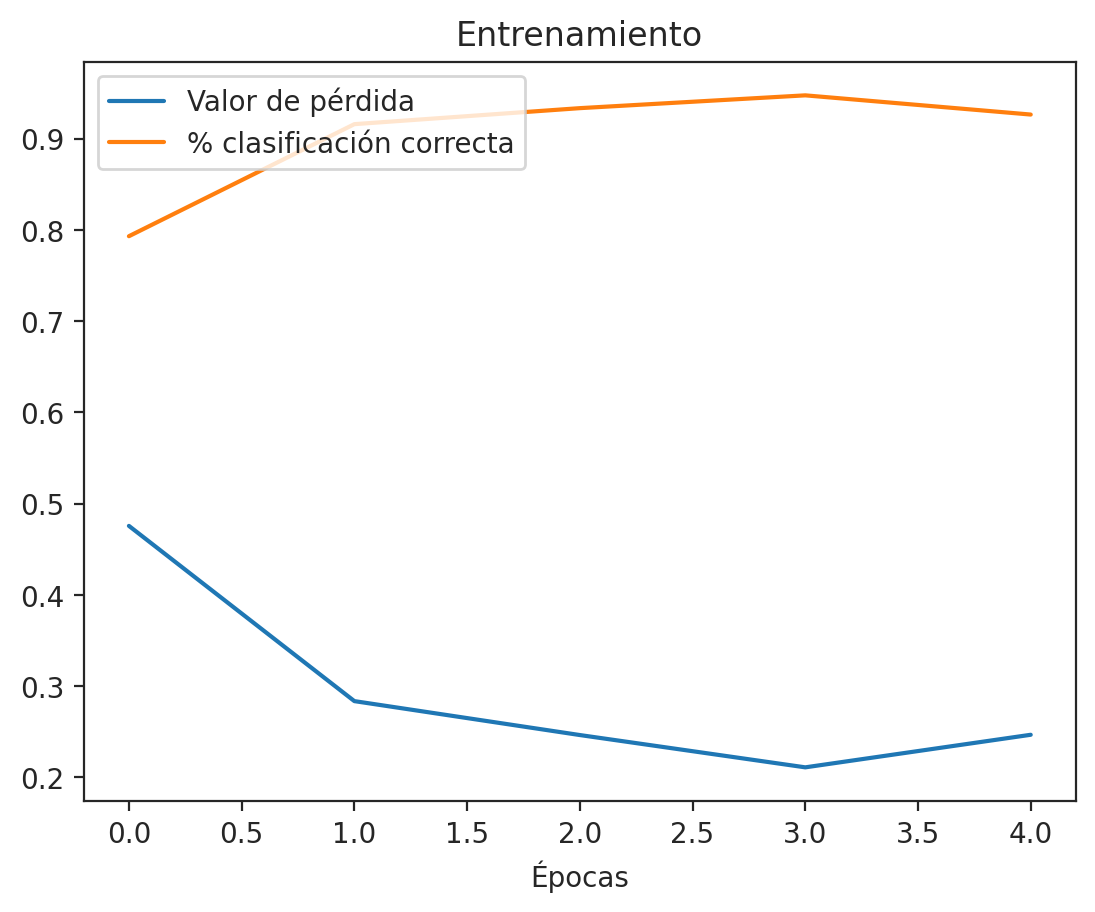

In [ ]:
plot_train_history(history_liver_bNorm, 'accuracy', '% clasificación correcta')

De las tres opciones propuestas para reducir el *overfitting* del modelo base, la que mejores resultados ha proporcionado ha sido la incorporación de ***Batch Normalization***. Esto se observa en los valores de *loss*, que son similares tanto en el conjunto de entrenamiento como en el de evaluación, y en la métrica de *accuracy*, que se mantiene estable en ambos conjuntos. Estos resultados sugieren que el modelo está generalizando bien a los datos no vistos previamente.

In [ ]:
# Guardamos ahora este último modelo
modelo_liver_bNorm.save(f'{path}/model_liver_v02.keras')

### Mejoras del modelo con ***Batch_Normalization***

Para mejorar el último modelo desarrollado, podemos modificar los hiperparámetros de la red como son el número de *epochs*, el *batch_size* y el *learning_rate*. Además, vamos a comparar 3 optimizadores diferentes (SGD, Adam, y RMSprop). Vamos a utilizar:

* Optimizador SGD con learning rates 0.01, 0.1, 0.25, y 0.5 con momentum.
* Optimizador Adam con learning rates 0.001, 0.01, y 0.1.
* Optimizador RMSprop con learning rates 0.001, 0.05, 0.01, y 0.1 con momentum.

En primer lugar cargamos el modelo que hemos generado.

In [ ]:
liver_model = keras.models.load_model(f'{path}/model_liver_v02.keras')

### Optimizador SGD

In [ ]:
# Para evaluar tiempo de ejecución
start_time = datetime.now()

# Optimizador SGD
learning = [0.01, 0.1, 0.25, 0.5]

for lr in learning:
  liver_model.compile(loss = 'binary_crossentropy',
                         optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum = 0.9, nesterov = True),
                         metrics = ['accuracy'])
  liver_model.fit(X_train, y_train, batch_size = 5, epochs = 20, verbose = False)
  test_loss, test_acc = liver_model.evaluate(X_test, y_test)

# Calculo del tiempo de ejecución
end_time = datetime.now()
print('Tiempo de ejecución Colab TPU: {}'.format(end_time - start_time))

3/3 [==============================] - 0s 6ms/step - loss: 1275526059710500600545280.0000 - accuracy: 0.5556
Tiempo de ejecución Colab TPU: 0:00:23.722514


Con el optimizador SGD, el mejor resultado corresponde a un *learning_rate* de 0.1, con un loss de 0.2528 y una accuracy de 93.06%. Este resultado ofrece un buen equilibrio entre un bajo loss y una alta accuracy, lo que indica que el modelo está bien ajustado y generaliza adecuadamente en los datos de prueba.

### Optimizador Adam

En este caso no usamos momentum.

In [ ]:
# Para evaluar tiempo de ejecución
start_time = datetime.now()

# Optimizador Adam
learning = [0.001, 0.05, 0.01, 0.1]

for lr in learning:
  liver_model.compile(loss = 'binary_crossentropy',
                         optimizer = tf.keras.optimizers.Adam(learning_rate=lr),
                         metrics = ['accuracy'])
  liver_model.fit(X_train, y_train, batch_size = 5, epochs = 20, verbose = False)
  test_loss, test_acc = liver_model.evaluate(X_test, y_test)

# Calculo del tiempo de ejecución
end_time = datetime.now()
print('Tiempo de ejecución Colab TPU: {}'.format(end_time - start_time))

3/3 [==============================] - 0s 7ms/step - loss: nan - accuracy: 0.4861
Tiempo de ejecución Colab TPU: 0:00:28.043469


Los resultados proporcionados con un *loss* de NaN y una *accuracy* de 48.61% indican que el modelo no está funcionando correctamente.

### Optimizador RMSProp

In [ ]:
# Para evaluar tiempo de ejecución
start_time = datetime.now()

# Optimizador RMSprop
learning = [0.001, 0.05, 0.01, 0.1]

for lr in learning:
  liver_model.compile(loss = 'binary_crossentropy',
                         optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr, momentum = 0.9),
                         metrics = ['accuracy'])
  liver_model.fit(X_train, y_train, batch_size = 5, epochs = 20, verbose = False)
  test_loss, test_acc = liver_model.evaluate(X_test, y_test)

# Calculo del tiempo de ejecución
end_time = datetime.now()
print('Tiempo de ejecución Colab TPU: {}'.format(end_time - start_time))

3/3 [==============================] - 0s 5ms/step - loss: nan - accuracy: 0.4861
Tiempo de ejecución Colab TPU: 0:00:19.566205


De nuevo, los resultados proporcionados con un *loss* de NaN y una *accuracy* de 48.61% indican que el modelo no está funcionando correctamente.

Del estudio realizado la mejor solución se obtiene con **SGD y learning rate de 0.1** (menor loss y accuracy de 0.93).

### Experimentación con epochs y batch_size

Utilizamos esa combinación como nuevo modelo para estudiar la influencia de epochs y el batch size. En este caso utilizamos los siguientes valores de los hiperparámetros:

* epochs = 10 de a 50 en incrementos de 10,
* batch_size = 4, 5, 6, 7, 8, 9, 10, 12, 14, 16.

El batch_size es pequeño porque estamos trabajando con pocas muestras en total en el conjunto de entrenamiento.

In [ ]:
# inicialización de bucles
epocas = range(10,51,10)
idx = range(0,len(epocas))
batch = [4, 5, 6, 7, 8, 9, 10, 12, 14, 16]
jdx = range(0,len(batch))

loss = np.zeros(shape=(len(epocas),len(batch)))
accu = np.zeros(shape=(len(epocas),len(batch)))

# red neuronal

# Bucle de cálculo
for i in idx:
  for j in jdx:
    print("Epocas: ", epocas[i], "; Batch: ", batch[j])
    liver_model.compile(loss = 'binary_crossentropy',
                         optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum = 0.9, nesterov = True),
                         metrics = ['accuracy'])
    liver_model.fit(X_train, y_train, batch_size = batch[j], epochs = epocas[i], verbose = False)
    test_loss, test_acc = liver_model.evaluate(X_test, y_test)
    loss[i,j] = test_loss
    accu[i,j] = test_acc

Epocas:  10 ; Batch:  4
3/3 [==============================] - 0s 3ms/step - loss: 0.3589 - accuracy: 0.9444
Epocas:  10 ; Batch:  5
3/3 [==============================] - 0s 3ms/step - loss: 0.4962 - accuracy: 0.9306
Epocas:  10 ; Batch:  6
3/3 [==============================] - 0s 3ms/step - loss: 0.5674 - accuracy: 0.9306
Epocas:  10 ; Batch:  7
3/3 [==============================] - 0s 3ms/step - loss: 0.5098 - accuracy: 0.9444
Epocas:  10 ; Batch:  8


3/3 [==============================] - 0s 3ms/step - loss: 0.6218 - accuracy: 0.9306
Epocas:  10 ; Batch:  9


3/3 [==============================] - 0s 3ms/step - loss: 0.9082 - accuracy: 0.9306
Epocas:  10 ; Batch:  10
3/3 [==============================] - 0s 3ms/step - loss: 0.7977 - accuracy: 0.9306
Epocas:  10 ; Batch:  12
3/3 [==============================] - 0s 3ms/step - loss: 0.8077 - accuracy: 0.9306
Epocas:  10 ; Batch:  14
3/3 [==============================] - 0s 3ms/step - loss: 0.6411 - accuracy: 0.9444
Epocas:  10 ; Batch:  16
3/3 [==============================] - 0s 3ms/step - loss: 0.6851 - accuracy: 0.9444
Epocas:  20 ; Batch:  4
3/3 [==============================] - 0s 3ms/step - loss: 0.2881 - accuracy: 0.9444
Epocas:  20 ; Batch:  5
3/3 [==============================] - 0s 3ms/step - loss: 0.6412 - accuracy: 0.9306
Epocas:  20 ; Batch:  6
3/3 [==============================] - 0s 3ms/step - loss: 0.3832 - accuracy: 0.9306
Epocas:  20 ; Batch:  7
3/3 [==============================] - 0s 3ms/step - loss: 0.4256 - accuracy: 0.9306
Epocas:  20 ; Batch:  8
3/3 [==========

Encontramos ahora la mejor combinación de épocas y batch_size:

In [ ]:
# Encuentra el índice de la mejor combinación
best_index = np.argmin(loss + 1e6 * (1 - accu))  # Suma un gran número al loss si accuracy es baja para evitar que el loss alto sea elegido

# Convierte el índice en índices de filas y columnas
best_i, best_j = np.unravel_index(best_index, loss.shape)

# Imprime la mejor combinación y sus métricas asociadas
print(f"Mejor combinación: Epocas = {epocas[best_i]}, Batch Size = {batch[best_j]}")
print(f"Pérdida (Loss) = {loss[best_i, best_j]}")
print(f"Accuracy = {accu[best_i, best_j]}")

Mejor combinación: Epocas = 20, Batch Size = 4
Pérdida (Loss) = 0.2880776822566986
Accuracy = 0.9444444179534912


De acuerdo con los resultados obtenidos hasta ahora, el optimizador que ha demostrado ser el más efectivo ha sido *SGD*, con una tasa de aprendizaje (*learning_rate*) de 0.1. En cuanto al tamaño de lote (*batch_size*) y el número de épocas (*epochs*), los mejores resultados se han obtenido con un tamaño de lote de 4 y 20 épocas, respectivamente.

In [ ]:
b_size = 4
epocas = 20

In [ ]:
# Para evaluar tiempo de ejecución
start_time = datetime.now()

liver_model.compile(loss = 'binary_crossentropy',
                        optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum = 0.9, nesterov=True),
                        metrics = ['accuracy'])

history_liver_01 = liver_model.fit(X_train, y_train, batch_size = b_size, epochs = epocas, verbose = False)
test_loss, test_acc = liver_model.evaluate(X_test, y_test)

# Calculo del tiempo de ejecución
end_time = datetime.now()
print('Tiempo de ejecución Colab TPU: {}'.format(end_time - start_time))

3/3 [==============================] - 0s 3ms/step - loss: 0.5182 - accuracy: 0.9167
Tiempo de ejecución Colab TPU: 0:00:02.560872


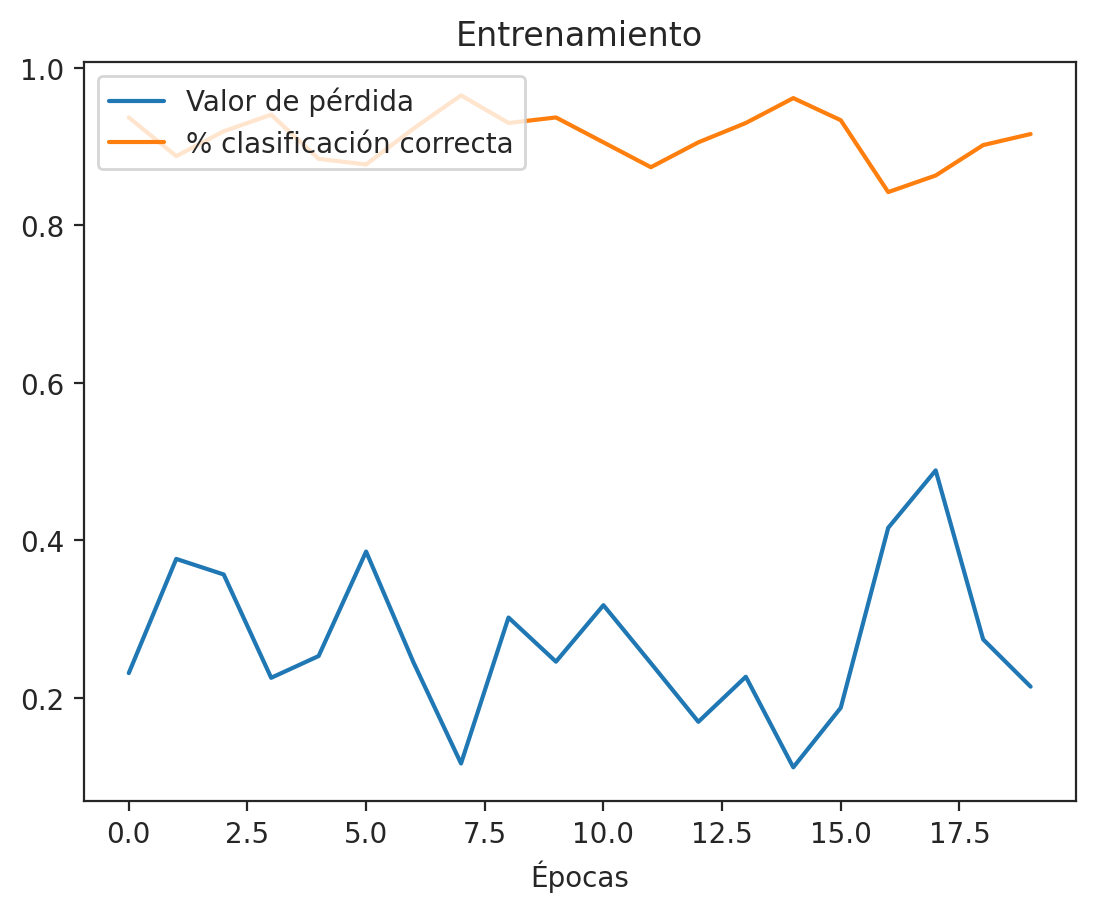

In [ ]:
# Gráficas
plot_train_history(history_liver_01, 'accuracy', '% clasificación correcta')

### Experimentación con cambios a nivel de estructura

Ahora vamos a estudiar el efecto que tiene el cambio de estructura de la red (aumento o disminución de neuronas y de capas ocultas) a partir del modelo obtenido en el punto anterior.

#### Misma arquitectura, cambio en número de neuronas

Primero vamos a mantener la arquitectura de la red pero modificando el número de neuronas de la capa oculta. Vamos a probar:

* Disminuir el número de neuronas a 4.
* Aumentar el número de neuronas a 16, 32 o 64.

In [ ]:
# Neuronas
neuronas = [4, 8, 16, 32, 64]

# red neuronal
initializer = tf.keras.initializers.GlorotNormal(123)

# Bucle de cálculo
for i in neuronas:
  print("Neuronas: ", i)
  # Arquitectura de red
  modelo_liver_03 = keras.Sequential([
      Input(shape=(X_train.shape[1],)),  # Forma de entrada
      Dense(i, activation='relu', kernel_initializer=initializer),
      BatchNormalization(),  # Normaliza la salida de la capa anterior
      Dense(1, activation='sigmoid')
  ])

  modelo_liver_03.compile(loss = 'binary_crossentropy',
                         optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum = 0.9, nesterov = True),
                         metrics = ['accuracy'])

  modelo_liver_03.fit(X_train, y_train, batch_size = b_size, epochs = epocas, verbose = False)
  test_loss, test_acc = modelo_liver_03.evaluate(X_test, y_test)

Neuronas:  4
3/3 [==============================] - 0s 3ms/step - loss: 0.2563 - accuracy: 0.9306
Neuronas:  8
3/3 [==============================] - 0s 3ms/step - loss: 0.4367 - accuracy: 0.9306
Neuronas:  16
3/3 [==============================] - 0s 3ms/step - loss: 0.3596 - accuracy: 0.9306
Neuronas:  32
3/3 [==============================] - 0s 3ms/step - loss: 0.3438 - accuracy: 0.9306
Neuronas:  64
3/3 [==============================] - 0s 3ms/step - loss: 0.3744 - accuracy: 0.9306


De acuerdo con estos resultados la mejor opción es utilizar una capa de 4 neuronas (loss: 0.2563 - accuracy: 0.9306). Vamos ahora a experimentar con el número de capas.

#### Cambio de arquitectura, mismo número de neuronas

Ahora modificamos la arquitectura de la red, cambiando el número de capas. Vamos a probar:
* Aumentar a dos capas ocultas
* Aumentar a tres capas ocultas

In [ ]:
# Análisis con 2 capas
# inicialización de bucles
neuronas = [4, 8, 16, 32, 64]

# red neuronal
initializer = tf.keras.initializers.GlorotNormal(123)
# Bucle de cálculo
for i in neuronas:
  print("Neuronas: ", i)
  # Arquitectura de red
  modelo_liver_03 = keras.Sequential([
      Input(shape=(X_train.shape[1],)),  # Forma de entrada
      Dense(i, activation='relu', kernel_initializer=initializer),
      BatchNormalization(),  # Normaliza la salida de la capa anterior
      Dense(i, activation='relu', kernel_initializer=initializer),
      BatchNormalization(),  # Normaliza la salida de la capa anterior
      Dense(1, activation='sigmoid')
  ])

  modelo_liver_03.compile(loss = 'binary_crossentropy',
                         optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum = 0.9, nesterov = True),
                         metrics = ['accuracy'])

  modelo_liver_03.fit(X_train, y_train, batch_size = b_size, epochs = epocas, verbose = False)
  test_loss, test_acc = modelo_liver_03.evaluate(X_test, y_test)

Neuronas:  4
3/3 [==============================] - 0s 3ms/step - loss: 0.2636 - accuracy: 0.9306
Neuronas:  8
3/3 [==============================] - 0s 3ms/step - loss: 0.3807 - accuracy: 0.8889
Neuronas:  16
3/3 [==============================] - 0s 3ms/step - loss: 0.2986 - accuracy: 0.9306
Neuronas:  32
3/3 [==============================] - 0s 3ms/step - loss: 0.3649 - accuracy: 0.9028
Neuronas:  64
3/3 [==============================] - 0s 3ms/step - loss: 0.2966 - accuracy: 0.9306


El aumento del número de capas no mejora los resultados anteriores, se mantienen estables prácticamente.

Vamos ahora a probar con una capa oculta más, haciendo un total de 3 capas ocultas.

In [ ]:
# Análisis con 3 capas
# inicialización de bucles
neuronas = [4, 8, 16, 32, 64]

# red neuronal
initializer = tf.keras.initializers.GlorotNormal(123)
# Bucle de cálculo
for i in neuronas:
  print("Neuronas: ", i)
  # Arquitectura de red
  modelo_liver_03 = keras.Sequential([
      Input(shape=(X_train.shape[1],)),  # Forma de entrada
      Dense(i, activation='relu', kernel_initializer=initializer),
      BatchNormalization(),  # Normaliza la salida de la capa anterior
      Dense(i, activation='relu', kernel_initializer=initializer),
      BatchNormalization(),  # Normaliza la salida de la capa anterior
      Dense(i, activation='relu', kernel_initializer=initializer),
      BatchNormalization(),  # Normaliza la salida de la capa anterior
      Dense(1, activation='sigmoid')
  ])

  modelo_liver_03.compile(loss = 'binary_crossentropy',
                         optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum = 0.9, nesterov = True),
                         metrics = ['accuracy'])

  modelo_liver_03.fit(X_train, y_train, batch_size = b_size, epochs = epocas, verbose = False)
  test_loss, test_acc = modelo_liver_03.evaluate(X_test, y_test)

Neuronas:  4
3/3 [==============================] - 0s 4ms/step - loss: 0.3932 - accuracy: 0.9028
Neuronas:  8
3/3 [==============================] - 0s 3ms/step - loss: 0.4715 - accuracy: 0.9306
Neuronas:  16
3/3 [==============================] - 0s 3ms/step - loss: 0.3876 - accuracy: 0.9306
Neuronas:  32
3/3 [==============================] - 0s 3ms/step - loss: 0.3188 - accuracy: 0.9306
Neuronas:  64
3/3 [==============================] - 0s 3ms/step - loss: 0.3400 - accuracy: 0.9306


De nuevo, no se produce una disminución de la pérdida y el porcentaje de clasificación correcta se mantiene igual. Por lo que nos quedamos con la opción de utilizar una sola capa con 4 neuronas.

In [ ]:
# Para evaluar tiempo de ejecución
start_time = datetime.now()

# red neuronal
initializer = tf.keras.initializers.GlorotNormal(123)

# Arquitectura de red
modelo_liver_03 = keras.Sequential([
      Input(shape=(X_train.shape[1],)),  # Forma de entrada
      Dense(4, activation='relu', kernel_initializer=initializer),
      BatchNormalization(),  # Normaliza la salida de la capa anterior
      Dense(1, activation='sigmoid')
  ])

# Configuración del proceso de aprendizaje
modelo_liver_03.compile(loss = 'binary_crossentropy',
                         optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum = 0.9, nesterov = True),
                         metrics = ['accuracy'])
# Entrenamiento
history_liver_03 = modelo_liver_03.fit(X_train, y_train, batch_size = 4, epochs = 20, verbose = False)
test_loss, test_acc = modelo_liver_03.evaluate(X_test, y_test)
# Calculo del tiempo de ejecución
end_time = datetime.now()
print('Tiempo de ejecución Colab TPU: {}'.format(end_time - start_time))

3/3 [==============================] - 0s 3ms/step - loss: 0.2442 - accuracy: 0.9306
Tiempo de ejecución Colab TPU: 0:00:03.401568


Vamos ahora a dibujar la gráfica:

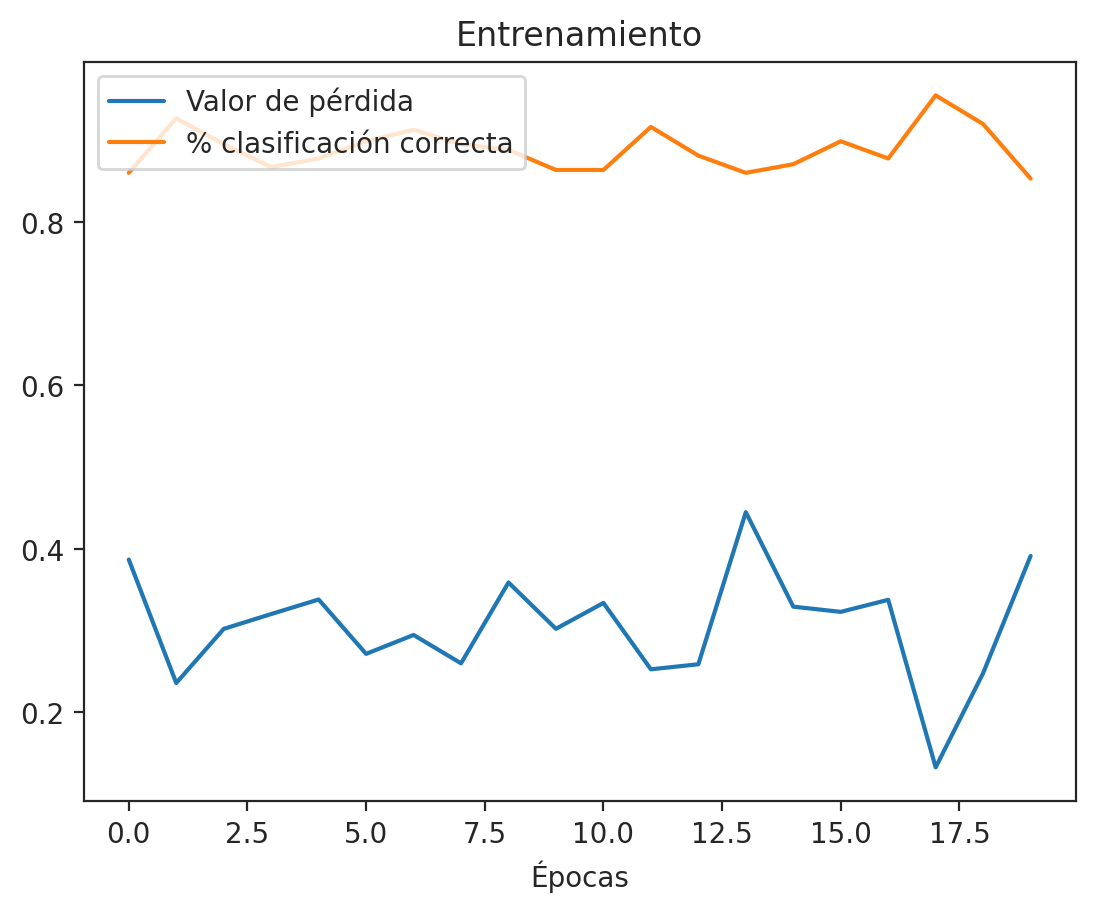

In [ ]:
plot_train_history(history_liver_03, 'accuracy', '% clasificación correcta')

In [ ]:
# Guardamos el modelo
modelo_liver_03.save(f'{path}/model_liver_v03.keras')

## Conclusiones

Este estudio ha analizado el impacto de diferentes optimizadores, tasas de aprendizaje, tamaños de lote, épocas de entrenamiento y variaciones en la arquitectura de la red sobre las métricas de rendimiento, específicamente *loss* y *accuracy*.

Los resultados obtenidos son bastante buenos, con un porcentaje de clasificación correcta (*accuracy*) de 0.9306 y un valor de pérdida (*loss*) de 0.2442. Durante el estudio, hemos visto que ha sido necesario aplicar técnicas para reducir el sobreajuste (*overfitting*), siendo la que mejores resultados ha conseguido la normalización por lotes (*batch_normalization*).

En este caso en el que contamos con pocas muestras, habría sido especialmente interesante utilizar validación cruzada (*cross validation*), tanto en su forma tradicional como en la variante *leave one out*. No obstante, esto requiere mayores recursos computacionales y extiende los tiempos de entrenamiento, por lo que en este caso no ha sido aplicado.